In [17]:
import sys
import os

sys.path.append(os.path.abspath("../src"))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns

pd.set_option("display.float_format", lambda x: f"{x:,.4f}")
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (12, 6)

from data_loader import (
    fetch_prices,
    compute_returns,
    describe_returns,
    jarque_bera,
    TICKERS,
    START_DATE,
    END_DATE,
)

from dcc_garch import (
    fit_univariate_garch,
    fit_dcc,
    get_dynamic_covariance,
)

from portfolio import (
    hrp_weights,
    benchmark_equal_weights,
    benchmark_static_hrp,
    benchmark_min_variance,
)

from evaluation import (
    sharpe_ratio,
    max_drawdown,
    calmar_ratio,
    metrics_table,
)

from plots import (
    plot_paired_correlation,
    plot_rolling_correlation,
    plot_dynamic_correlations,
    plot_dendogram,
)

In [18]:
prices = fetch_prices()
returns = compute_returns(prices)

print(f"Number of assets: {len(TICKERS)}")
print(f"Timeframe: {START_DATE} -> {END_DATE}")
print(f"Shape of prices: {prices.shape}")
print(f"Shape of returns: {returns.shape}")
print(f"First available date of returns: {returns.index[0].date()}")
print(f"Last available date of returns: {returns.index[-1].date()}")

Loading data from cache: ../data/prices.parquet
Number of assets: 16
Timeframe: 2011-10-10 -> 2026-01-01
Shape of prices: (3578, 16)
Shape of returns: (3577, 16)
First available date of returns: 2011-10-11
Last available date of returns: 2025-12-31


In [19]:
prices.tail()

Ticker,AGG,GLD,HYG,IEF,IWM,LQD,QQQ,SPY,SVXY,TIP,TLT,XLE,XLF,XLK,XLU,XLV
Date,,,,,,,,,,,,,,,,
2025-12-24,98.3876,411.9300,78.6495,94.8091,252.2613,108.5753,623.1443,688.4997,54.9300,108.2481,86.3960,44.0820,55.4450,146.1183,42.5128,155.1621
2025-12-26,98.4073,416.7400,78.6104,94.8977,250.9736,108.5655,623.1043,688.4299,55.0000,108.2383,86.1114,43.9131,55.3356,146.3480,42.4830,155.4111
2025-12-29,98.5253,398.6000,78.6397,95.0355,249.4363,108.7127,620.0881,685.9766,55.3700,108.3366,86.4352,44.3304,55.0371,145.6889,42.5624,155.1721
2025-12-30,98.4860,398.8900,78.7177,94.9370,247.5896,108.5851,618.6499,685.1389,55.6900,108.3170,86.2291,44.6682,54.8978,145.2294,42.6617,155.0426
2025-12-31,98.2499,396.3100,78.6397,94.6222,245.7229,108.1239,613.5364,680.0627,55.3800,108.1006,85.5421,44.4198,54.4899,143.7912,42.3936,154.1662


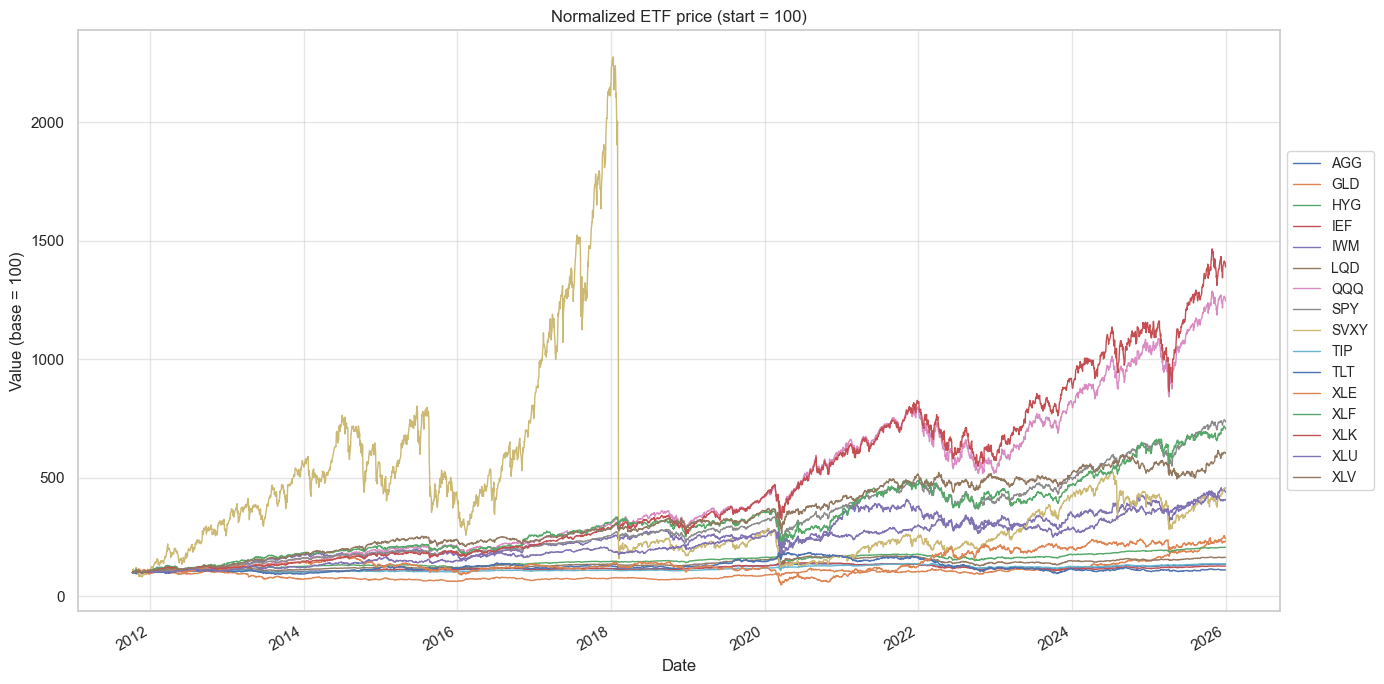

In [20]:
# Price normalization for better comparison
normalized_prices = prices / prices.iloc[0] * 100

normalized_prices.plot(figsize=(14, 7), linewidth=1)
plt.title("Normalized ETF price (start = 100)")
plt.xlabel("Date")
plt.ylabel("Value (base = 100)")
plt.legend(loc="center left", bbox_to_anchor=(1.0, 0.5), ncol=1, fontsize="small")
plt.tight_layout()
plt.show()

In [21]:
describe_returns(returns)

            count   mean    std     min     25%    50%    75%    max
Ticker                                                              
AGG    3,577.0000 0.0001 0.0030 -0.0408 -0.0013 0.0002 0.0016 0.0234
GLD    3,577.0000 0.0002 0.0098 -0.0919 -0.0048 0.0005 0.0054 0.0479
HYG    3,577.0000 0.0002 0.0051 -0.0565 -0.0018 0.0002 0.0023 0.0634
IEF    3,577.0000 0.0001 0.0041 -0.0254 -0.0023 0.0002 0.0025 0.0261
IWM    3,577.0000 0.0004 0.0136 -0.1423 -0.0066 0.0009 0.0079 0.0875
LQD    3,577.0000 0.0001 0.0049 -0.0513 -0.0021 0.0004 0.0025 0.0713
QQQ    3,577.0000 0.0007 0.0130 -0.1276 -0.0047 0.0012 0.0074 0.1134
SPY    3,577.0000 0.0006 0.0106 -0.1159 -0.0036 0.0007 0.0057 0.0999
SVXY   3,577.0000 0.0004 0.0445 -1.7695 -0.0102 0.0041 0.0171 0.1254
TIP    3,577.0000 0.0001 0.0035 -0.0291 -0.0017 0.0002 0.0020 0.0436
TLT    3,577.0000 0.0000 0.0093 -0.0690 -0.0056 0.0005 0.0056 0.0725
XLE    3,577.0000 0.0002 0.0173 -0.2249 -0.0077 0.0006 0.0087 0.1487
XLF    3,577.0000 0.0005 0.0133 -0

In [22]:
jarque_bera(returns)

=== JB Test Summary ===
100.0% of the ETFs completely reject the assumption of normality (p < 0.05).


In [23]:
# High count of rejections of normality (JB) and statistically significant kurtosis
# potwierdzają zasadność użycia rozkładu t-Studenta w modelach GARCH
# zamiast standardowego rozkładu normalnego.

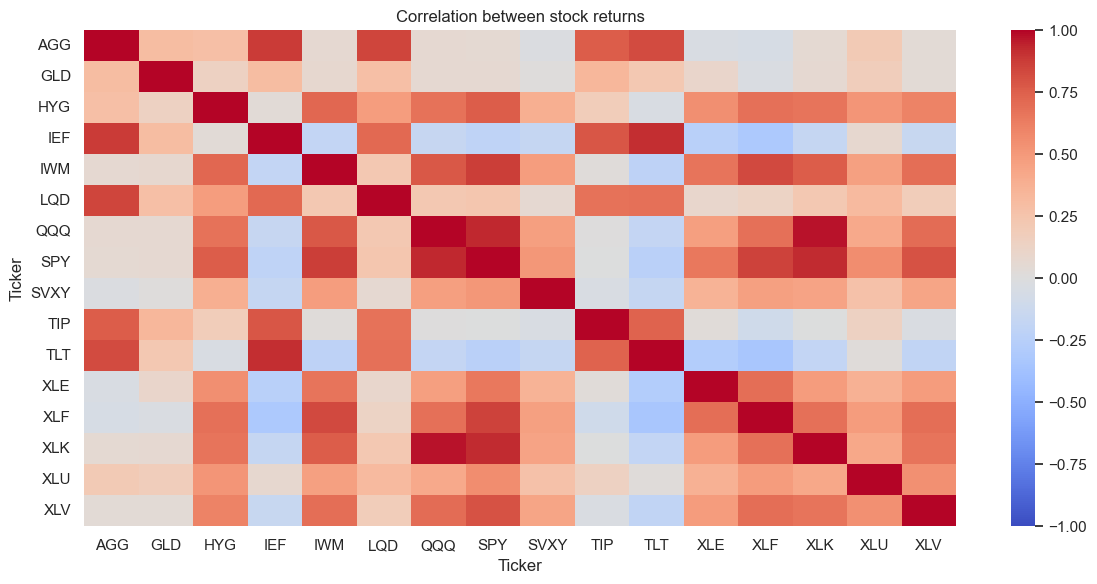

In [24]:
plot_paired_correlation(returns)

In [25]:
# ============================================================
# SECTION 2: GARCH Diagnostics (univariate)
# ============================================================
# We check if the univariate GARCH(1,1) models correctly found
# ARCH effects in the returns, before we use standardized
# residuals as inputs in the DCC model.

In [26]:
std_resid, vols = fit_univariate_garch(returns)

print(f"Shape of std_resid: {std_resid.shape}")
print(f"Shape of  vols: {vols.shape}")
std_resid.describe().T[["mean", "std"]]

Shape of std_resid: (3577, 16)
Shape of  vols: (3577, 16)


,mean,std
AGG,-0.0232,1.0030
GLD,-0.0057,0.9942
HYG,-0.0527,0.9960
IEF,-0.0047,1.0017
IWM,-0.0386,1.0003
LQD,-0.0325,1.0018
QQQ,-0.0720,0.9888
SPY,-0.0702,0.9948
SVXY,-0.1136,1.0115
TIP,-0.0167,1.0004


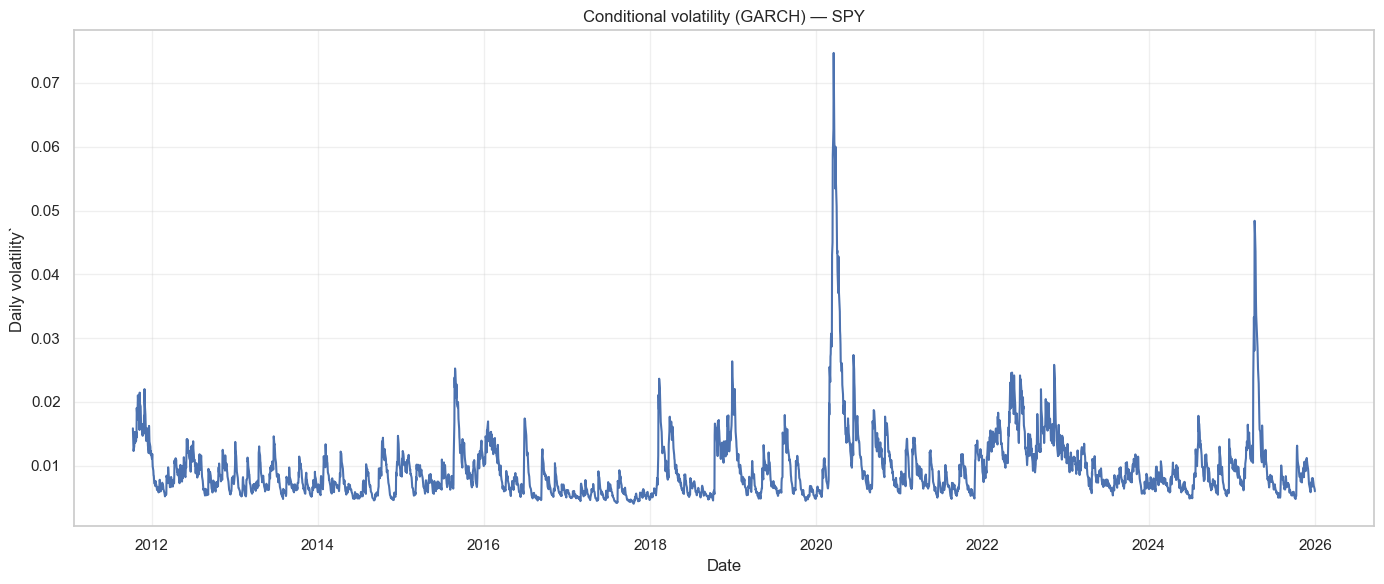

In [27]:
plt.figure(figsize=(14, 6))
plt.plot(vols.index, vols["SPY"])
plt.title("Conditional volatility (GARCH) — SPY")
plt.xlabel("Date")
plt.ylabel("Daily volatility`")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

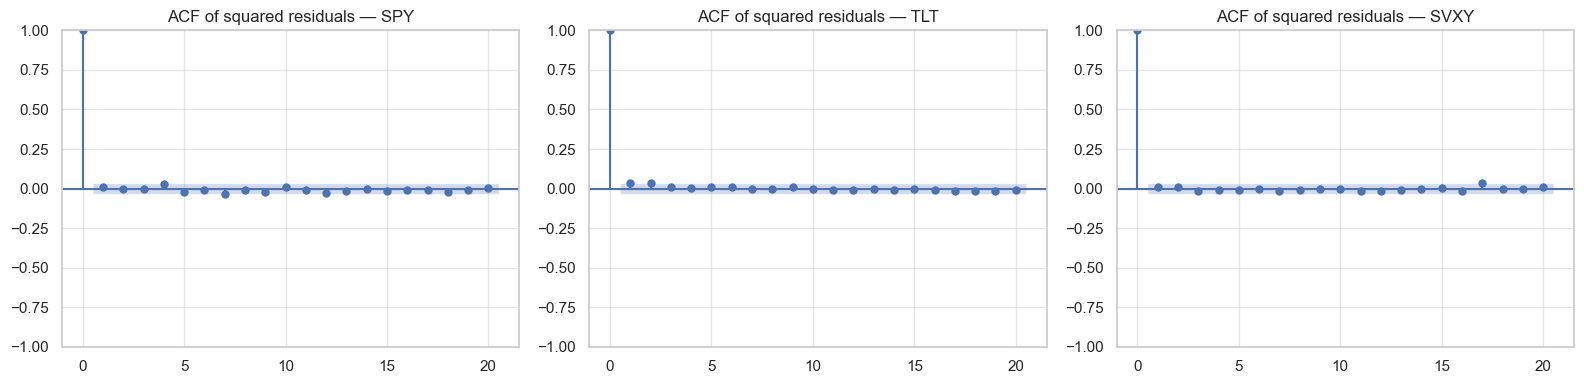

In [28]:
from statsmodels.graphics.tsaplots import plot_acf

assets_to_check = ["SPY", "TLT", "SVXY"]

fig, axes = plt.subplots(1, len(assets_to_check), figsize=(16, 4))

for ax, asset in zip(axes, assets_to_check):
    squared_resid = std_resid[asset] ** 2
    plot_acf(squared_resid, ax=ax, lags=20, title=f"ACF of squared residuals — {asset}")

plt.tight_layout()
plt.show()

In [29]:
from arch import arch_model

garch_params = {}

for asset in returns.columns:
    y = returns[asset].dropna()
    current_variance = np.var(y)
    rescale_factor = 1.0 / np.sqrt(current_variance) if current_variance > 0 else 1.0
    y_scaled = y * rescale_factor

    model = arch_model(y_scaled, p=1, q=1, dist='t')
    res = model.fit(disp="off", show_warning=False)

    garch_params[asset] = {
        "omega": res.params["omega"],
        "alpha[1]": res.params["alpha[1]"],
        "beta[1]": res.params["beta[1]"],
        "alpha+beta": res.params["alpha[1]"] + res.params["beta[1]"],
    }

garch_params_df = pd.DataFrame(garch_params).T
garch_params_df

,omega,alpha[1],beta[1],alpha+beta
AGG,0.0110,0.0878,0.8991,0.9869
GLD,0.0124,0.0417,0.9470,0.9887
HYG,0.0105,0.1662,0.8326,0.9988
IEF,0.0097,0.0571,0.9329,0.9900
IWM,0.0195,0.0963,0.8838,0.9801
LQD,0.0116,0.0797,0.9046,0.9843
QQQ,0.0190,0.1417,0.8494,0.9911
SPY,0.0238,0.1741,0.8119,0.9860
SVXY,0.0335,0.3214,0.6786,1.0000
TIP,0.0195,0.0800,0.8977,0.9776


In [30]:
# Note:
# SVXY stands out as the only ETF with alpha+beta ~= 1.0 (close to IGARCH),
# suggesting highly persistent (non-mean-reverting) volatility shocks.
# This is consistent with the nature of the instrument (a short-VIX ETF),
# which experienced a severe "blow-up" in February 2018.

In [31]:
# ============================================================
# SECTION 3: DCC Diagnostics
# ============================================================
# Here i check the fit of the DCC model - how persistent the
# conditional correlation is over time, and whether correlations
# between specific asset pairs have behaved as expected (e. g. rising
# during crisis periods, such as COVID-19).

In [36]:
dcc_results = fit_dcc(std_resid.values)

alpha = dcc_results['alpha']
beta = dcc_results['beta']
loglik = dcc_results['loglik']

print(f"alpha: {alpha:.4f}")
print(f"beta: {beta:.4f}")
print(f"alpha + beta: {alpha + beta:.4f}")
print(f"log-likelihood: {loglik:.4f}")

alpha: 0.0150
beta: 0.9760
alpha + beta: 0.9910
log-likelihood: 35921.2908


In [ ]:
# alpha + beta = 0.9910 indicates that the conditional correlation
# structure is highly persistent over time — shocks to correlation
# (e.g. during market stress) decay very slowly. This is a typical
# and expected result for daily financial data (unlike the univariate
# GARCH case for SVXY, where alpha+beta ~= 1.0 signaled a genuine
# stationarity concern for variance).

In [38]:
cov_history_3D = get_dynamic_covariance(vols, dcc_results)
print(f"cov_history_3D shape: {cov_history_3D.shape}")

cov_history_3D shape: (3577, 16, 16)


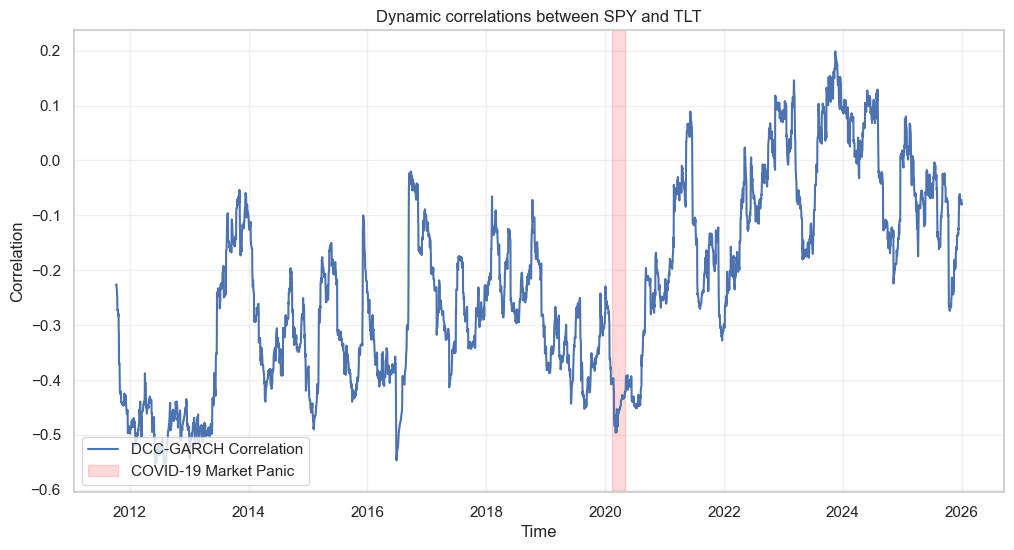

In [39]:
plot_dynamic_correlations(dcc_results, returns, 'SPY', 'TLT')

In [ ]:
# Contrary to the simplest "flight to safety" narrative, SPY-TLT
# correlation during COVID-19 (~-0.50) was not the most extreme
# value in the sample — a comparable or stronger negative
# correlation (~-0.55) occurred around 2013 and 2016. This may reflect the
# high persistence of the DCC model (alpha+beta ~= 0.99), which
# smooths short, sharp regime shifts, and/or the well-documented
# "dash for cash" episode in March 2020, when equities and bonds
# briefly sold off together before flight-to-safety dynamics
# reasserted themselves.

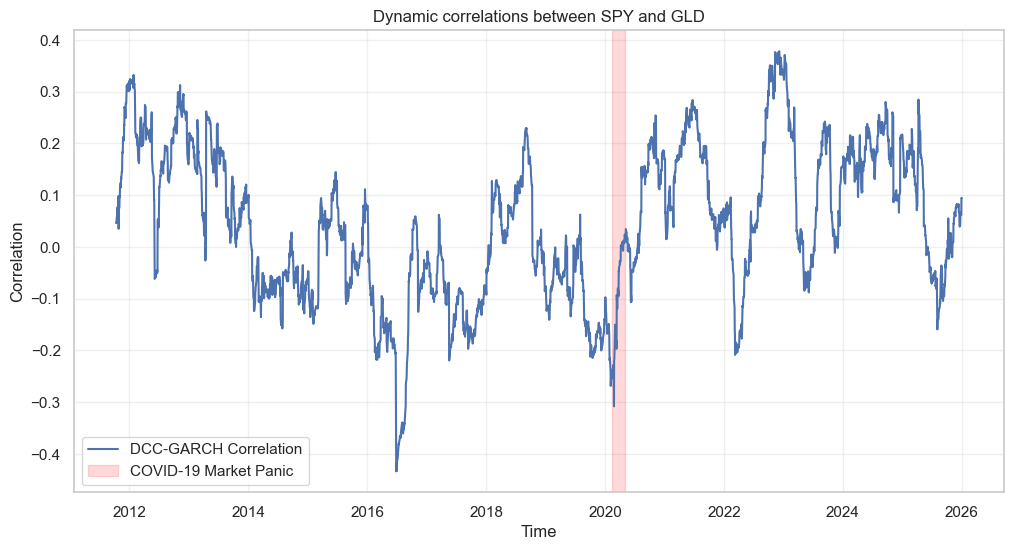

In [40]:
plot_dynamic_correlations(dcc_results, returns, 'SPY', 'GLD')

In [ ]:
# The same pattern holds for SPY-GLD as for SPY-TLT: the 2016 period
# shows a stronger negative correlation (~-0.45) than COVID-19
# (~-0.30). Since this pattern is consistent across two different
# "safe haven" pairs, it is unlikely to be pair-specific noise.
# A plausible explanation is the high persistence of the fitted DCC
# model (alpha+beta ~= 0.99): a short, sharp shock like the COVID-19
# crash may not have had enough time to fully propagate into the
# correlation estimate before markets began to recover, whereas the
# 2016 episode may have been more prolonged, allowing the smoothed
# DCC correlation to reach a more extreme value.

In [ ]:
# Comparison: rolling correlation vs DCC-GARCH correlation (SPY-TLT)
#
# To test whether the high persistence of the fitted DCC model
# (alpha+beta ~= 0.99) smooths out short, sharp shocks like the
# COVID-19 crash, I compare it against a simple rolling-window
# correlation (60 days), which applies no such smoothing.
#
# If the rolling correlation shows a deeper, sharper dip during
# COVID-19 than the DCC-GARCH correlation, this would support the
# earlier hypothesis: the DCC model's persistence may prevent it
# from fully capturing brief, extreme regime shifts.

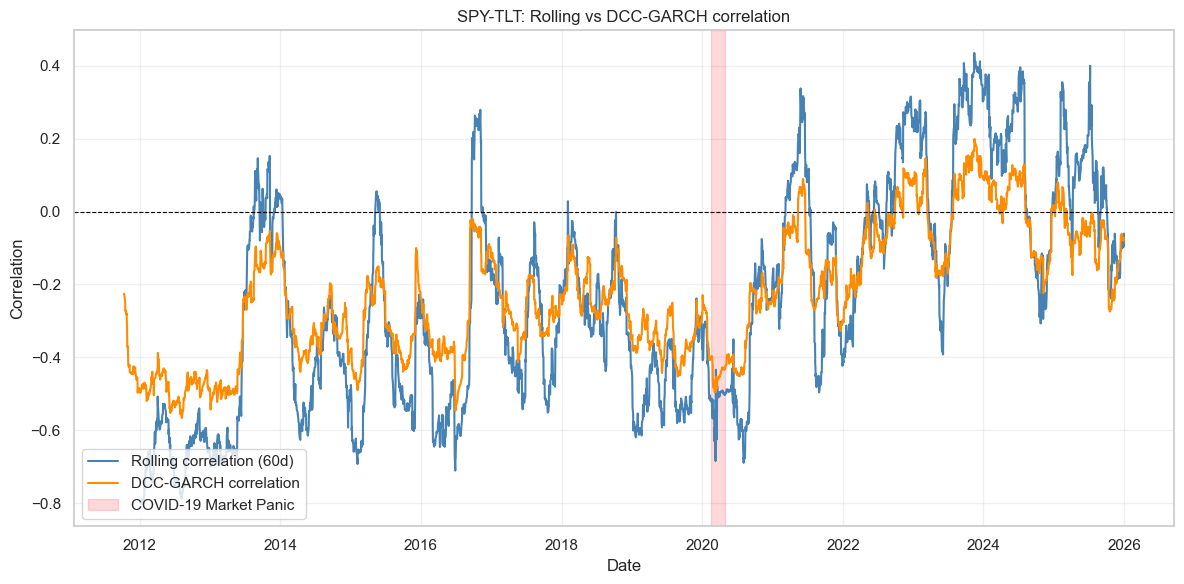

In [41]:
window = 60

rolling_corr_spy_tlt = returns["SPY"].rolling(window).corr(returns["TLT"])

plt.figure(figsize=(12, 6))
plt.plot(returns.index, rolling_corr_spy_tlt, label=f"Rolling correlation ({window}d)", color="steelblue")
plt.plot(returns.index, dcc_results["R"][:, returns.columns.get_loc("SPY"), returns.columns.get_loc("TLT")],
         label="DCC-GARCH correlation", color="darkorange")
plt.axvspan("2020-02-15", "2020-04-30", color="red", alpha=0.15, label="COVID-19 Market Panic")
plt.axhline(0, color="black", linewidth=0.8, linestyle="--")
plt.title("SPY-TLT: Rolling vs DCC-GARCH correlation")
plt.xlabel("Date")
plt.ylabel("Correlation")
plt.legend(loc="lower left")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [ ]:
# The plot shows that DCC-GARCH consistently smooths the correlation
# compared to the rolling 60-day correlation - but not specifically
# during COVID-19. In fact, during the COVID-19 window (highlighted
# in red), the rolling and DCC lines track each other closely. The
# clearest gaps between the two series appear in other periods
# (e.g. 2016-2017, 2023-2024), suggesting the smoothing effect of
# high DCC persistence is a general property of the model rather
# than something specific to sudden crisis regimes.
#
# Personally, this was surprising to me - I initially expected the
# COVID-19 shock to be the period most affected by DCC smoothing,
# given how sudden and extreme it was. The data suggests otherwise.

In [ ]:
# Comparison: rolling correlation vs DCC-GARCH correlation (SPY-GLD)
#
# Repeating the same comparison as for SPY-TLT, to check whether the
# smoothing behavior of the DCC model observed above is a general
# property of the model, or specific to the SPY-TLT pair.

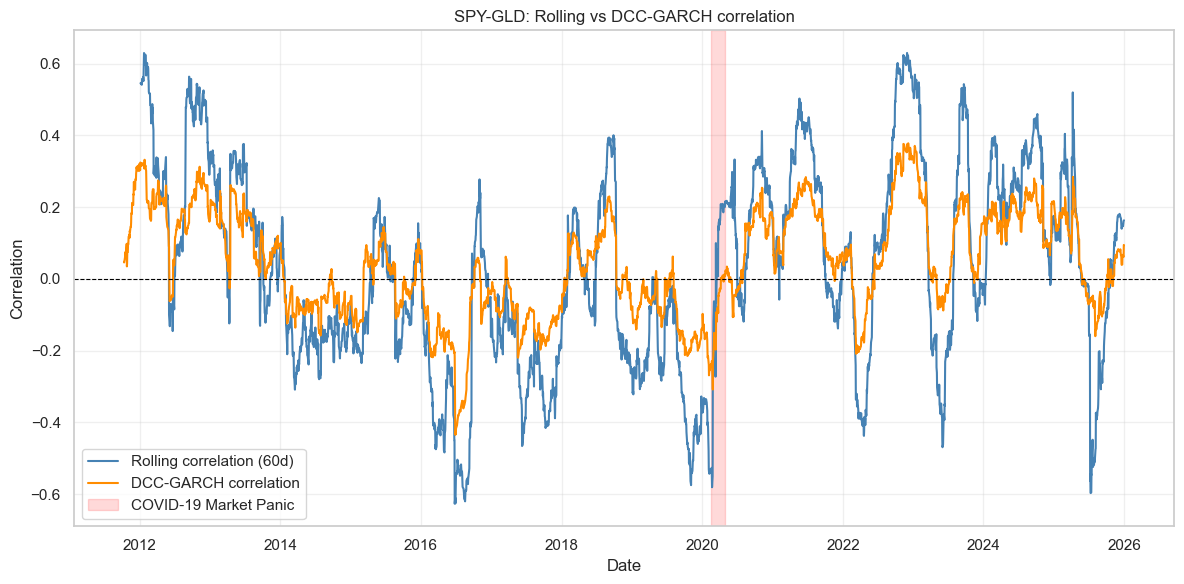

In [42]:
rolling_corr_spy_gld = returns["SPY"].rolling(window).corr(returns["GLD"])

plt.figure(figsize=(12, 6))
plt.plot(returns.index, rolling_corr_spy_gld, label=f"Rolling correlation ({window}d)", color="steelblue")
plt.plot(returns.index, dcc_results["R"][:, returns.columns.get_loc("SPY"), returns.columns.get_loc("GLD")],
         label="DCC-GARCH correlation", color="darkorange")
plt.axvspan("2020-02-15", "2020-04-30", color="red", alpha=0.15, label="COVID-19 Market Panic")
plt.axhline(0, color="black", linewidth=0.8, linestyle="--")
plt.title("SPY-GLD: Rolling vs DCC-GARCH correlation")
plt.xlabel("Date")
plt.ylabel("Correlation")
plt.legend(loc="lower left")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [ ]:
# The SPY-GLD comparison confirms the pattern observed for SPY-TLT:
# the DCC-GARCH correlation consistently tracks below the peaks and
# above the troughs of the rolling correlation throughout the entire
# sample, not just during COVID-19. During the COVID-19 window itself,
# the two series again move closely together - the largest gaps
# between rolling and DCC correlation occur in unrelated periods
# (e.g. 2012, 2016-2017, 2025).
#
# This strengthens the earlier conclusion: the smoothing effect of
# the high-persistence DCC model (alpha+beta ~= 0.99) is a general,
# structural property of the model, not something specific to sudden
# crisis regimes like COVID-19.

In [ ]:
# ============================================================
# SECTION 4: Portfolio structure (single time slice)
# ============================================================
# I inspect the HRP clustering structure and compare portfolio
# weights across all four allocation methods (HRP-DCC, Equal-Weight,
# Static HRP, Min-Variance) for a single point in time — the last
# available day in the sample.

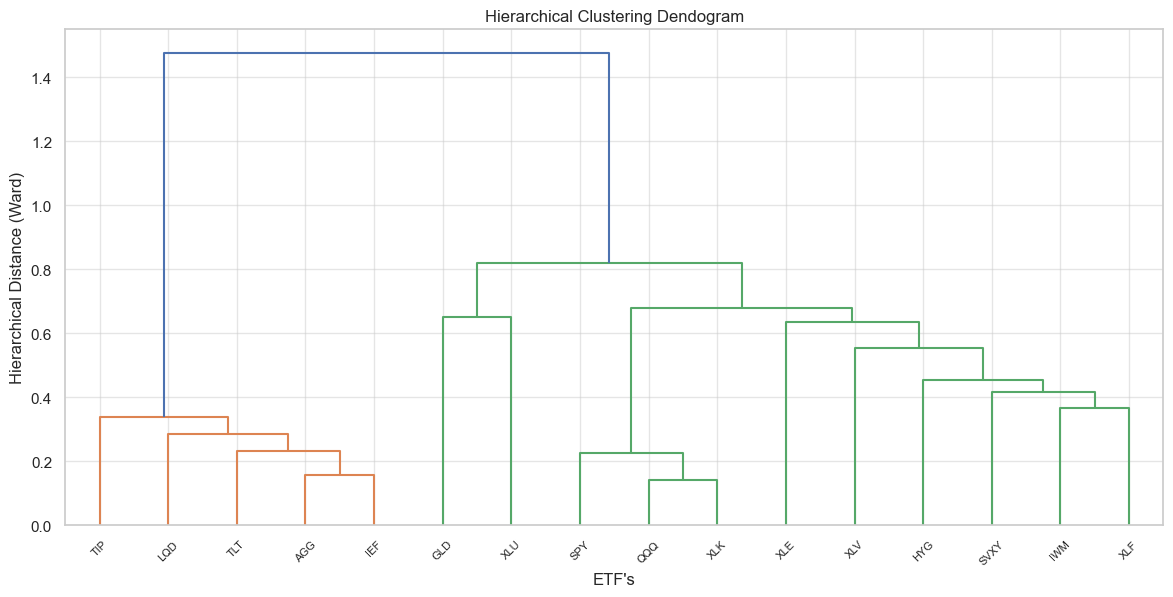

In [43]:
single_day_cov = cov_history_3D[-1, :, :]

final_weights, linkage_matrix = hrp_weights(single_day_cov)

plot_dendogram(linkage_matrix, asset_names=list(returns.columns))

In [ ]:
# Interpretation:
# [TODO: after inspecting the dendrogram — do the clusters make
# economic sense? E.g. do equities (SPY, QQQ, IWM, XLF, XLE, XLV,
# XLU, XLK) group together and separately from fixed income
# (AGG, TLT, IEF, HYG, LQD)? Where does GLD/TIP/SVXY fall?]

In [ ]:
w_hrp = final_weights
w_ew = benchmark_equal_weights(single_day_cov)
w_static = benchmark_static_hrp(returns)
w_min_var = benchmark_min_variance(single_day_cov)

comparison_df = pd.DataFrame({
    "HRP (DCC)": w_hrp * 100,
    "Equal-Weight": w_ew * 100,
    "Static HRP (LW)": w_static * 100,
    "Min-Variance": w_min_var * 100,
}, index=returns.columns)

comparison_df.round(2)

In [ ]:
print("Weight sums (should all be ~100%):")
print(comparison_df.sum().round(4))

In [ ]:
# Interpretation:
# [TODO: after inspecting the table — does HRP avoid extreme
# concentration (e.g. no single asset >30-40%)? How does it compare
# to Min-Variance, which is known to sometimes concentrate heavily
# in a few low-volatility assets? Does Static HRP (Ledoit-Wolf) look
# similar to HRP-DCC, or meaningfully different?]